# Estaciones del SMN en Tamaulipas — cobertura y ubicación

Qué estaciones climatológicas convencionales del Servicio Meteorológico Nacional
sirven de verdad para el periodo 2020 en adelante, y dónde están.

Dos fuentes, y **no cubren lo mismo**:

| archivo | qué trae | coordenadas |
|---|---|---|
| `estaciones_convencionales_tamps.csv` | el **catálogo**: 199 estaciones, con su situación (Operando / Suspendida) | **no** |
| `temperatura_diaria_tamps_2020.csv` | las **series diarias** descargadas, de 2020 en adelante | sí |

De ahí sale la limitación que gobierna todo el cuaderno: **solo se puede ubicar
en un mapa una estación que tenga datos**. Las que no descargaron nada se cuentan
y se listan, pero no se dibujan — no hay dónde ponerlas.

Documentación completa en [`README.md`](README.md).

## 1. Preparación

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

# El cuaderno vive dos niveles por debajo de la raíz del repo.
RAIZ = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if RAIZ not in sys.path:
    sys.path.insert(0, RAIZ)

from smn import cobertura as K
from smn import config as SC
from smn.mapa import mapa_estaciones

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

### El periodo real

El archivo se llama `..._2020.csv` porque 2020 es el año de **inicio**, no el
único. El periodo se lee del propio dato para que una re-descarga no deje la
cobertura mal calculada en silencio.

In [2]:
lo, hi, dias = K.periodo()
print(f"{lo:%Y-%m-%d} a {hi:%Y-%m-%d} = {dias} días")

2020-01-01 a 2026-09-10 = 2445 días


## 2. Las preguntas, contestadas

`resumen()` da los números de un vistazo.

In [3]:
t = K.tabla()          # una fila por estación del CATÁLOGO (199), tenga datos o no
r = K.resumen(t)
for k, v in r.items():
    print(f"{k:28s} {v}")

periodo                      2020-01-01 .. 2026-09-10
dias_periodo                 2445
catalogo                     199
con_datos                    117
sin_datos                    82
desde_2020                   99
siguen_activas               65
cobertura_mediana            78.6
cobertura_media              62.0
cob>=50%                     77
cob>=50%_y_desde_2020        73
cob>=75%                     59
cob>=75%_y_desde_2020        58
cob>=90%                     39
cob>=90%_y_desde_2020        39
cob>=95%                     24
cob>=95%_y_desde_2020        24


Lo esencial:

- **199** estaciones en el catálogo.
- **117** tienen datos descargados; **82 no tienen ninguno**.
- **99** arrancan en 2020 (el resto empieza más tarde).
- Con el filtro por omisión —desde 2020 y **≥ 75 %** de cobertura— quedan **58**.

La mediana de cobertura (78.6 %) está muy por encima de la media (62 %): hay un
grupo grande de estaciones casi completas y una cola de estaciones con muy poco
dato que arrastra el promedio.

### ¿"Operando" significa que hay datos?

No del todo, y tampoco al revés.

In [4]:
K.por_situacion(t)

tiene datos,False,True
situación,,
Operando,4,109
Suspendida,78,8


Cuatro estaciones marcadas **Operando** no descargaron un solo día, y ocho
**Suspendidas** sí tienen histórico. La situación del catálogo es un dato
administrativo: no sustituye a mirar la cobertura real.

### Las que no tienen nada

In [5]:
sin = K.sin_datos(t)
print(f"{len(sin)} estaciones sin un solo día descargado")
sin.head(12)

82 estaciones sin un solo día descargado


,clave,nombre,municipio,situacion
0,28004,Altamira (Smn),Altamira,Suspendida
1,28005,El Refugio (Smn),Antiguo Morelos,Suspendida
2,28006,Barberena,Altamira,Suspendida
3,28011,Fraccionamiento Callejones,Ocampo,Suspendida
4,28012,C.E.I. Ciudad Mante,El Mante,Suspendida
5,28014,S.J. 2-11 Camargo,Camargo,Suspendida
6,28016,Campo Experimental Cuauhtemoc,Altamira,Operando
7,28025,Ejido Tres De Mayo (Cfe),Altamira,Suspendida
8,28026,El Aguacate,González,Suspendida
9,28030,El Ocotillal,Jiménez,Suspendida


## 3. Cobertura estación por estación

`cobertura` se mide sobre el **periodo completo**; `cobertura_activa`, sobre el
tramo propio de cada estación (de su primera a su última fecha). La diferencia
entre las dos es diagnóstica: si `cobertura` es baja pero `cobertura_activa` es
alta, la estación no tiene huecos — simplemente empezó tarde o dejó de reportar.

In [6]:
cols = ["clave", "nombre", "municipio", "situacion", "primera", "ultima",
        "n_dias", "cobertura", "cobertura_activa", "banda"]
t[t.tiene_datos][cols].head(15)

,clave,nombre,municipio,situacion,primera,ultima,n_dias,cobertura,cobertura_activa,banda
0,28002,Ahualulco,Gómez Farías,Operando,2020-01-01,2026-09-10,2442,99.877301,99.877301,alta
1,28059,Magueyes,Mainero,Operando,2020-01-01,2026-08-31,2435,99.591002,100.000000,alta
2,28087,San Gabriel,Xicoténcatl,Operando,2020-01-01,2026-09-10,2433,99.509202,99.509202,alta
3,28028,El Barretal I,Padilla,Operando,2020-01-01,2026-08-31,2427,99.263804,99.671458,alta
4,28147,Tamesi,González,Operando,2020-01-01,2026-09-10,2424,99.141104,99.141104,alta
5,28049,La Servilleta,El Mante,Operando,2020-01-01,2026-09-10,2423,99.100204,99.100204,alta
6,28044,La Encantada,Llera,Operando,2020-01-01,2026-08-31,2400,98.159509,98.562628,alta
7,28070,Padilla,Padilla,Operando,2020-01-01,2026-08-31,2399,98.118609,98.521561,alta
8,28083,Sabinas,Gómez Farías,Operando,2020-01-01,2026-09-10,2399,98.118609,98.118609,alta
9,28019,Cruillas,Cruillas,Operando,2020-01-01,2026-08-31,2396,97.995910,98.398357,alta


In [7]:
# El caso contrario: reportan sin huecos, pero solo una parte del periodo
casi = t[t.tiene_datos & (t.cobertura < 60) & (t.cobertura_activa > 90)]
print(f"{len(casi)} estaciones sin huecos internos pero con poco periodo cubierto")
casi[cols].head(10)

18 estaciones sin huecos internos pero con poco periodo cubierto


,clave,nombre,municipio,situacion,primera,ultima,n_dias,cobertura,cobertura_activa,banda
73,28047,La Loba,Jiménez,Operando,2020-01-01,2024-02-29,1379,56.400818,90.664037,baja
77,28164,La Angostura,Llera,Operando,2021-10-01,2024-12-30,1149,46.993865,96.798652,baja
82,28010,Bustamante,Bustamante,Operando,2020-02-01,2022-03-31,729,29.815951,92.278481,baja
88,28027,El Mulato,Burgos,Operando,2020-01-01,2021-09-30,639,26.134969,100.000000,baja
89,28045,La Encarnacion,Soto La Marina,Operando,2020-01-01,2021-09-30,626,25.603272,97.965571,baja
95,28199,Guadalupe,San Carlos,Operando,2025-04-01,2026-06-29,422,17.259714,92.747253,baja
100,28163,El Carrizal,Aldama,Operando,2020-01-01,2020-07-31,212,8.670757,99.530516,baja
101,28116,Ciudad Victoria (Dge),Victoria,Suspendida,2024-09-01,2025-03-31,211,8.629857,99.528302,baja
103,28196,La Cabecera,Aldama,Suspendida,2020-01-01,2020-07-17,199,8.139059,100.000000,baja
104,28066,Nuevo Morelos,Nuevo Morelos,Suspendida,2020-01-01,2020-07-13,195,7.975460,100.000000,baja


### Distribución

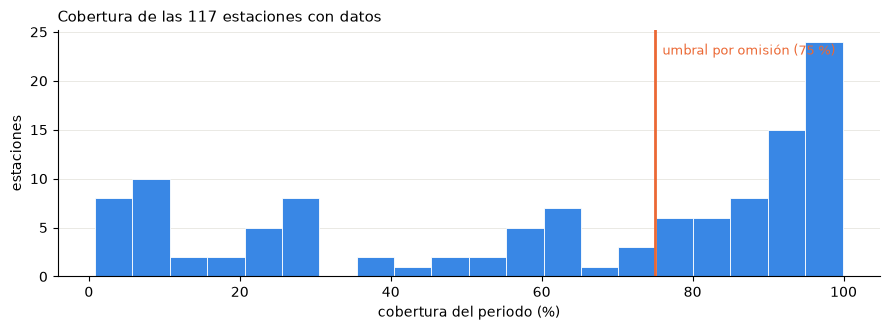

In [8]:
con = t[t.tiene_datos]
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(con.cobertura, bins=20, color="#3987e5", edgecolor="white", linewidth=0.6)
ax.axvline(SC.COBERTURA_MIN_OMISION, color="#eb6834", lw=2)
ax.text(SC.COBERTURA_MIN_OMISION + 1, ax.get_ylim()[1] * 0.9,
        f"umbral por omisión ({SC.COBERTURA_MIN_OMISION:g} %)",
        color="#eb6834", fontsize=9)
ax.set_xlabel("cobertura del periodo (%)")
ax.set_ylabel("estaciones")
ax.set_title("Cobertura de las 117 estaciones con datos", loc="left", fontsize=11)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.grid(axis="y", lw=.5, color="#e1e0d9")
ax.set_axisbelow(True)
fig.tight_layout();

La distribución es claramente bimodal: un bloque de estaciones que cubren casi
todo el periodo y otro que apenas reporta. No hay mucho en medio, lo que es una
buena noticia para elegir umbral — mover el corte entre 70 y 85 % cambia poco.

### Cuántas sobreviven a cada umbral

In [9]:
pd.DataFrame([
    {"umbral %": u,
     "con datos": int((con.cobertura >= u).sum()),
     "y desde 2020": int(((con.cobertura >= u) & con.desde_2020).sum())}
    for u in (0, 25, 50, 60, 75, 85, 90, 95, 99)
])

,umbral %,con datos,y desde 2020
0,0,117,99
1,25,90,82
2,50,77,73
3,60,71,69
4,75,59,58
5,85,47,47
6,90,39,39
7,95,24,24
8,99,6,6


### Cobertura por variable

`tmax_c` y `tmin_c` vienen siempre que hay fila; `precip_mm` casi siempre; pero
**`evap_mm` falta en 4 de cada 5 días**, así que no se puede tratar como una
serie más.

In [10]:
vars_cob = [c for c in t.columns if c.startswith("cob_")]
t.loc[t.tiene_datos, vars_cob].describe().round(1)

,cob_tmax_c,cob_tmin_c,cob_temp_media_c,cob_precip_mm,cob_evap_mm
count,117.0,117.0,117.0,117.0,117.0
mean,62.0,62.0,62.0,59.8,12.9
std,34.6,34.6,34.6,34.8,26.1
min,0.8,0.8,0.8,0.8,0.0
25%,26.7,26.7,26.7,26.1,0.0
50%,78.6,78.6,78.6,69.6,0.0
75%,92.5,92.5,92.5,92.4,4.9
max,99.9,99.9,99.9,99.5,92.9


## 4. El mapa

Por omisión dibuja **solo las estaciones con datos desde 2020 y al menos 75 %**
de cobertura, sobre la división política municipal del INEGI — la misma base y
la misma paleta que los mapas de `urbano/`.

El color codifica la cobertura en una rampa de **un solo tono**: más oscuro es
más completo. Al ser una variable ordinal, un esquema rojo/amarillo/verde
obligaría a consultar la leyenda para saber cuál es "mejor" (y tropieza con el
daltonismo justo en ese par).

[mapa] /home/team-e/Documentos/DSI/Proyecto_Radiacion_Solar/Results/smn/estaciones_smn_cob75.png
58 estaciones dibujadas


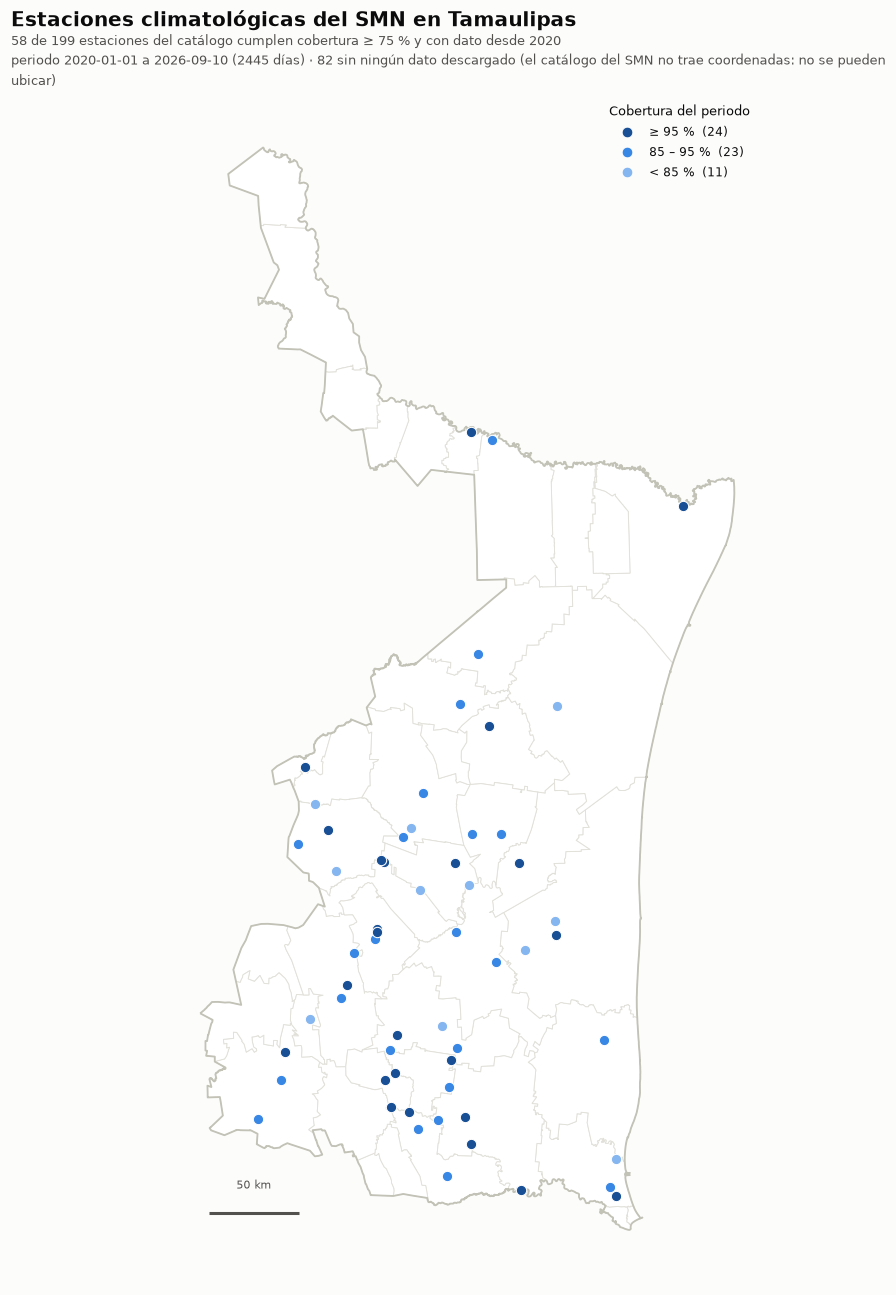

In [11]:
fig, sel = mapa_estaciones(tabla=t)
print(f"{len(sel)} estaciones dibujadas")

El vacío del **norte** salta a la vista: entre Nuevo Laredo, Reynosa y Matamoros
—donde vive la mayor parte de la población del estado— apenas hay estaciones que
pasen el filtro, mientras el centro-sur está densamente cubierto. Para cualquier
validación de datos satelitales contra estaciones, eso condiciona qué zonas se
pueden contrastar y cuáles no.

### Ver qué se está dejando fuera

`mostrar_descartadas=True` pinta en gris las que tienen datos pero no pasan el
filtro. Sirve para comprobar que el umbral no está tirando una región entera.

[mapa] /home/team-e/Documentos/DSI/Proyecto_Radiacion_Solar/Results/smn/estaciones_smn_cob75.png


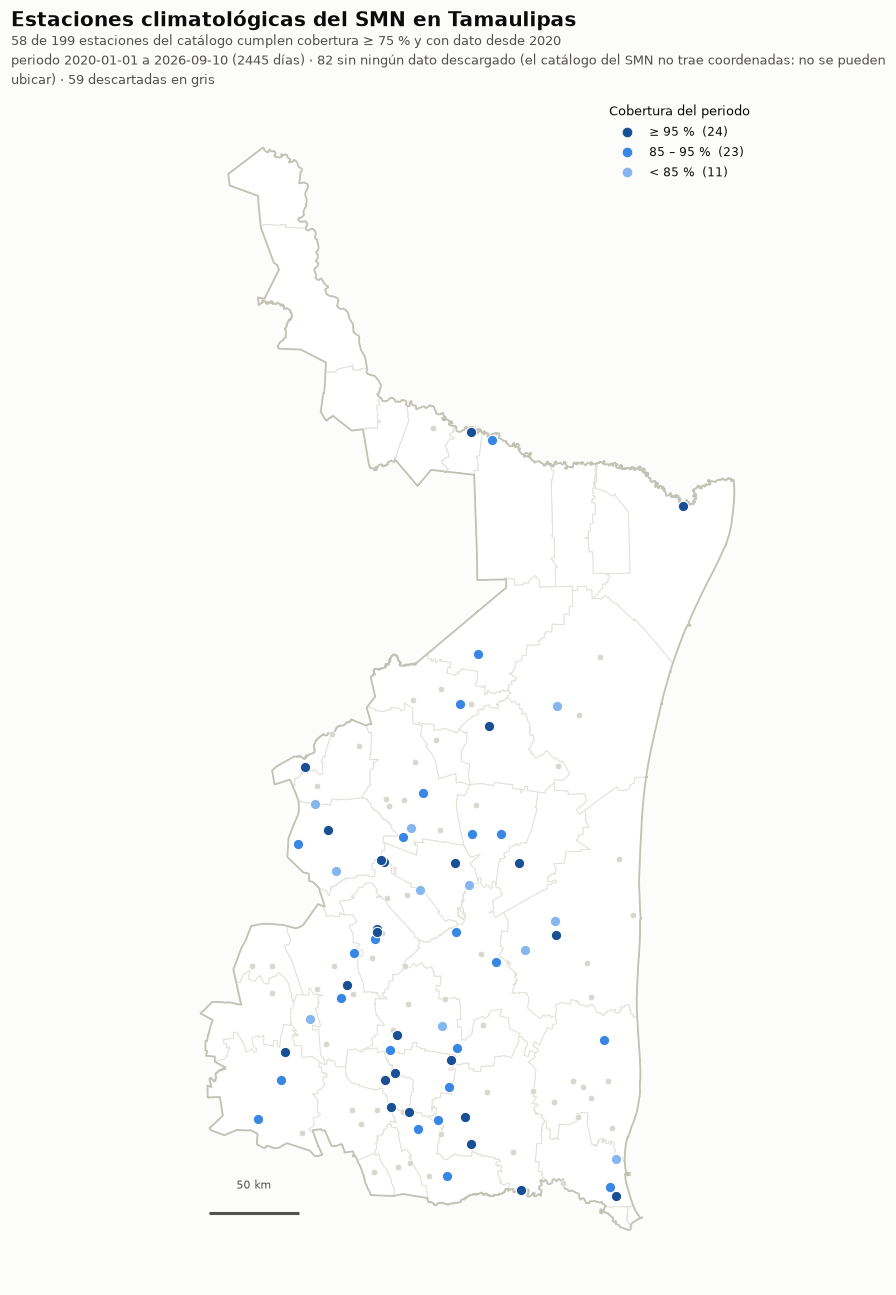

In [12]:
fig, sel = mapa_estaciones(tabla=t, mostrar_descartadas=True);

Las descartadas se reparten por todo el estado, así que subir o bajar el umbral
no cambia el sesgo espacial: el hueco del norte es de la red, no del filtro.

### Otros umbrales

[mapa] /home/team-e/Documentos/DSI/Proyecto_Radiacion_Solar/Results/smn/estaciones_smn_cob95.png
24 estaciones con cobertura ≥ 95 %


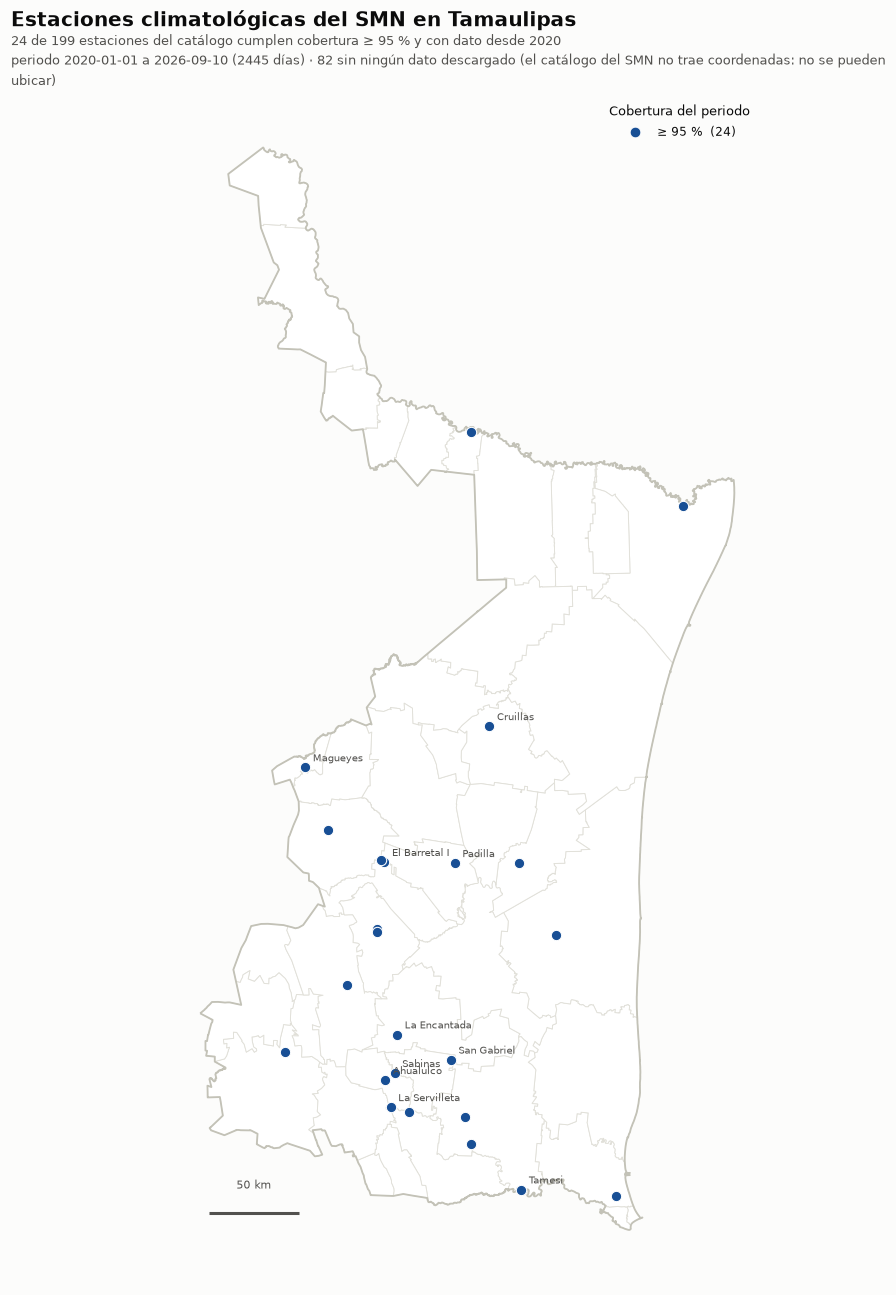

In [13]:
fig, sel = mapa_estaciones(tabla=t, cobertura_min=95, etiquetar=10)
print(f"{len(sel)} estaciones con cobertura ≥ 95 %")

[mapa] /home/team-e/Documentos/DSI/Proyecto_Radiacion_Solar/Results/smn/estaciones_smn_cob0.1.png
117 estaciones


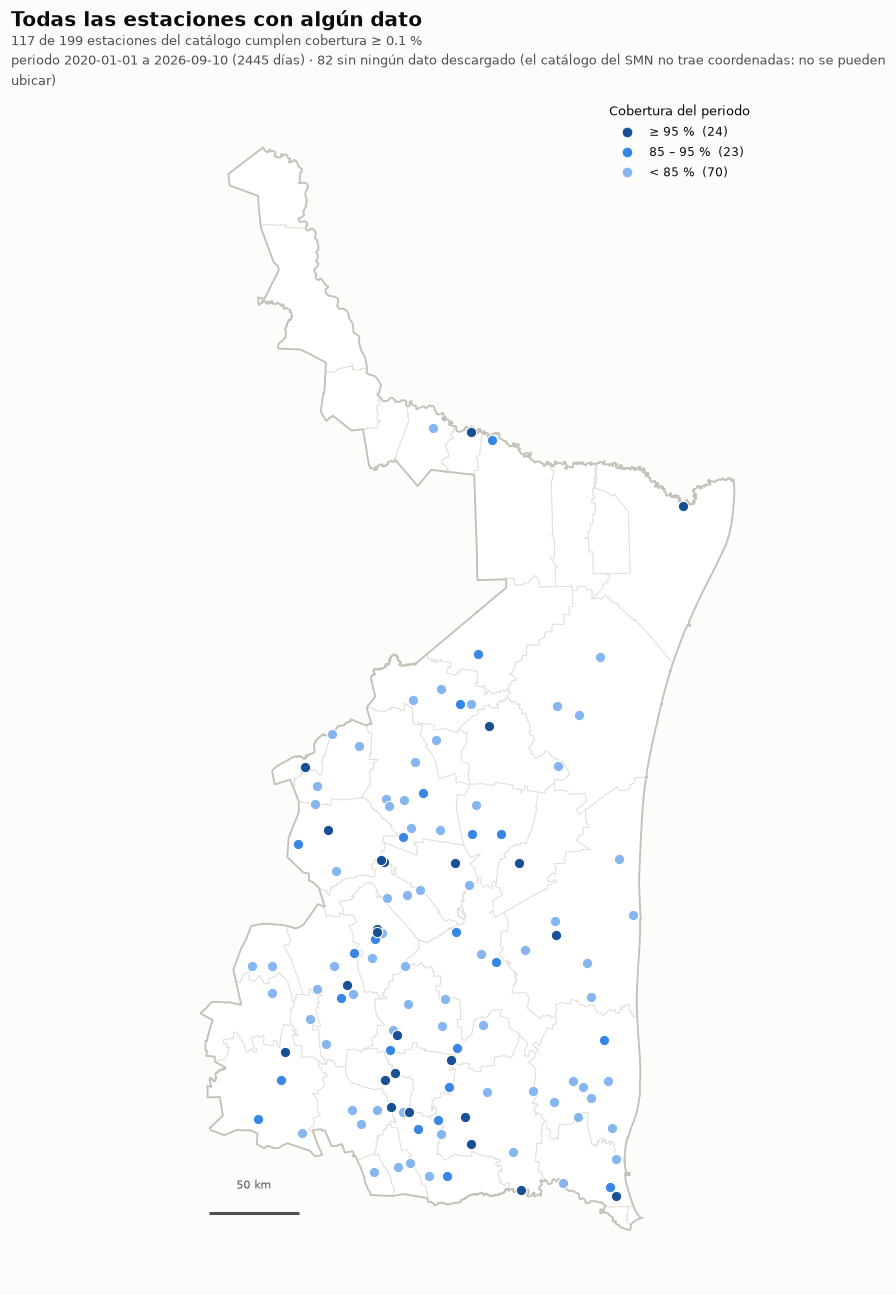

In [14]:
# Sin ningún filtro: las 117 que tienen algún dato
fig, sel = mapa_estaciones(tabla=t, desde_2020=False, cobertura_min=0.1,
                           titulo="Todas las estaciones con algún dato")
print(f"{len(sel)} estaciones")

### Textos a medida

`titulo` y `subtitulo` se autogeneran si no se pasan, se sustituyen con una
cadena, y se quitan con `""`.

[mapa] /home/team-e/Documentos/DSI/Proyecto_Radiacion_Solar/Results/smn/estaciones_smn_cob90.png


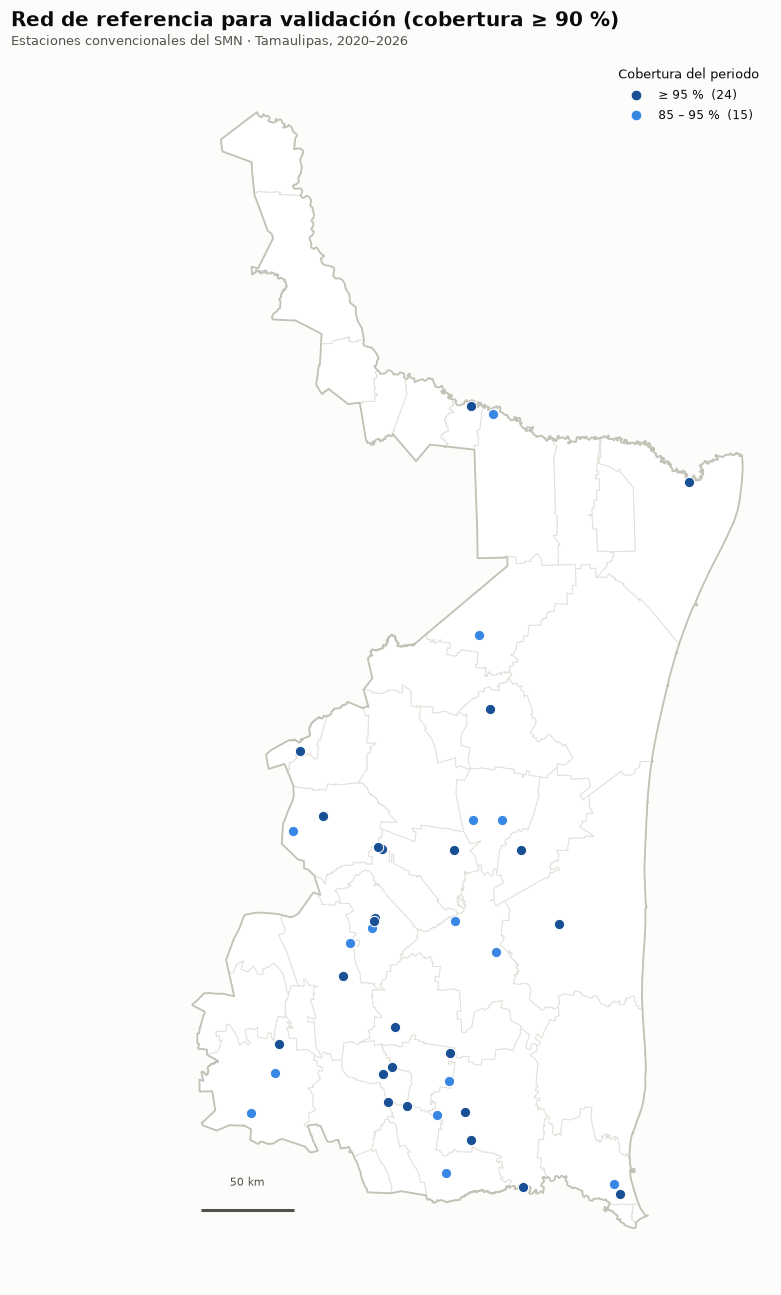

In [15]:
fig, sel = mapa_estaciones(
    tabla=t, cobertura_min=90,
    titulo="Red de referencia para validación (cobertura ≥ 90 %)",
    subtitulo="Estaciones convencionales del SMN · Tamaulipas, 2020–2026");

### Sobre mapa base

`base=True` pega un mosaico de OpenStreetMap debajo. Necesita red la primera vez;
después usa `cache/tiles/`. Si la red falla, la figura se genera igual sin fondo
en vez de romper.

[mapa] /home/team-e/Documentos/DSI/Proyecto_Radiacion_Solar/Results/smn/estaciones_smn_cob75_base.png


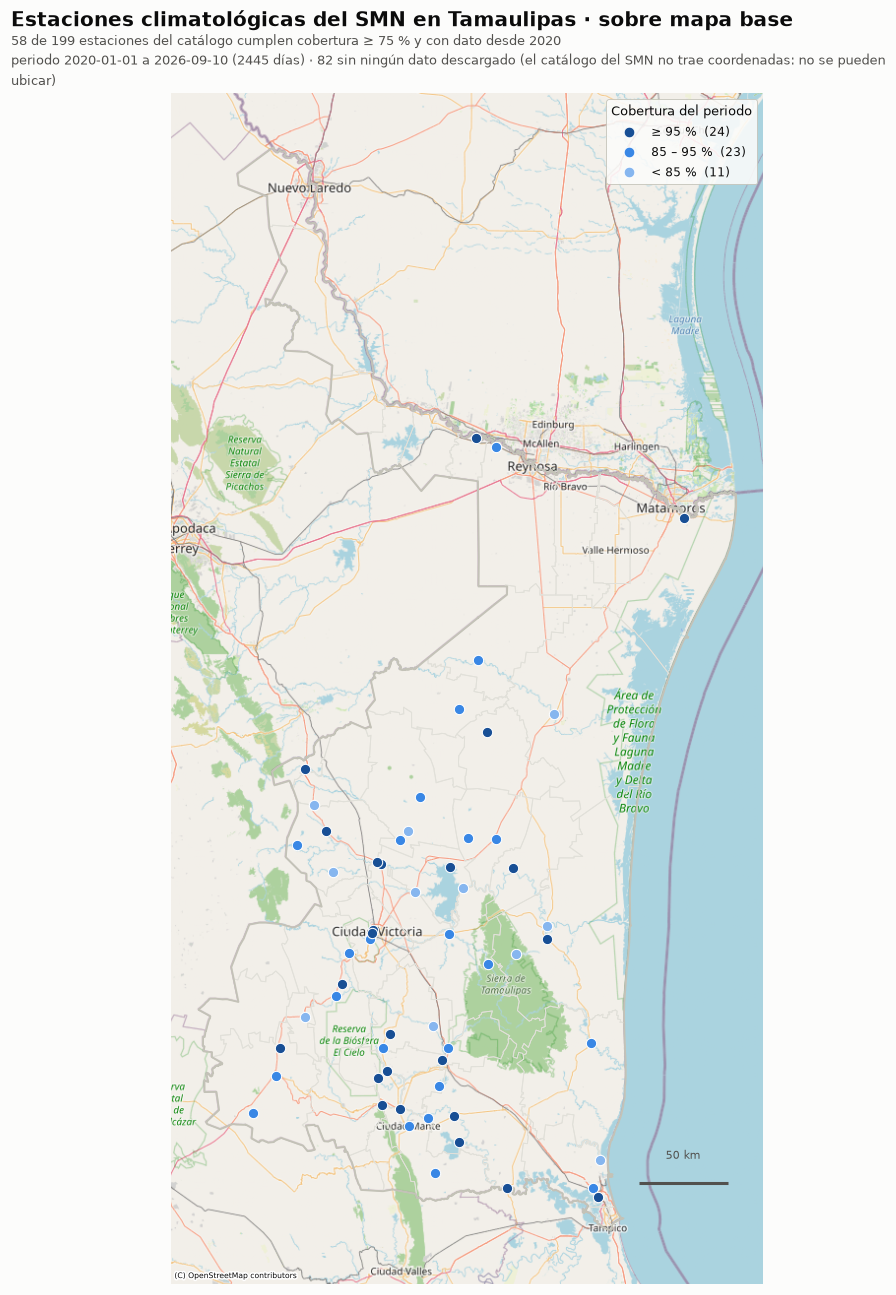

In [16]:
fig, sel = mapa_estaciones(tabla=t, base=True);

## 5. Exportar

La tabla completa por estación, para usarla fuera del cuaderno.

In [17]:
salida = os.path.join(RAIZ, "Results", "smn", "cobertura_estaciones.csv")
os.makedirs(os.path.dirname(salida), exist_ok=True)
t.to_csv(salida, index=False)
print(f"{len(t)} filas -> {salida}")

199 filas -> /home/team-e/Documentos/DSI/Proyecto_Radiacion_Solar/Results/smn/cobertura_estaciones.csv


---

## Resumen de la API

```python
from smn import cobertura as K
from smn.mapa import mapa_estaciones

K.periodo()                      # (primera, última, n_días) del archivo
K.tabla()                        # una fila por estación del catálogo (199)
K.resumen()                      # los conteos de un vistazo
K.seleccionar(cobertura_min=75)  # las que pasan el filtro
K.por_situacion()                # situación del catálogo × tiene datos
K.sin_datos()                    # las 82 que no descargaron nada

mapa_estaciones(desde_2020=True, cobertura_min=75, mostrar_descartadas=False,
                base=False, etiquetar=0, titulo=None, subtitulo=None,
                ruta=None, tabla=None)
```

Y desde la terminal:

```bash
conda run -n rs python -m smn.cobertura --cobertura-min 90
conda run -n rs python -m smn.mapa --cobertura-min 90 --descartadas --base
```